In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from engine.noise import fbm, perlin, simplex, billow, ridged
from engine.mesh import normalize

In [ ]:
with open("../config.yaml", 'r') as f:
    config = yaml.safe_load(f)

terrain = config["terrain"]
noise = config["noise"]
render = config.get("render", {})

In [ ]:
noise_type = noise["type"]

if noise["type"] == "perlin":
    hm = perlin(
        terrain["width"],
        terrain["height"],
        scale=noise["scale"],
        seed=noise.get("seed")
    )

elif noise["type"] == "fbm":
    hm = fbm(
        terrain["width"],
        terrain["height"],
        scale=noise["scale"],
        octaves=noise.get("octaves", 4),
        persistence=noise.get("persistence", 0.5),
        lacunarity=noise.get("lacunarity", 2.0),
        seed=noise.get("seed")
    )

elif noise["type"] == "simplex":
    hm = simplex(
        terrain["width"],
        terrain["height"],
        scale=noise["scale"],
        seed=noise.get("seed")
    )

elif noise["type"] == "billow":
    hm = billow(
        terrain["width"],
        terrain["height"],
        scale=noise["scale"],
        octaves=noise.get("octaves", 4),
        seed=noise.get("seed")
    )

elif noise["type"] == "ridged":
    hm = ridged(
        terrain["width"],
        terrain["height"],
        scale=noise["scale"],
        octaves=noise.get("octaves", 4),
        seed=noise.get("seed")
    )

else: raise ValueError(f"Unknown noise type: {noise_type}")

hm = normalize(hm)

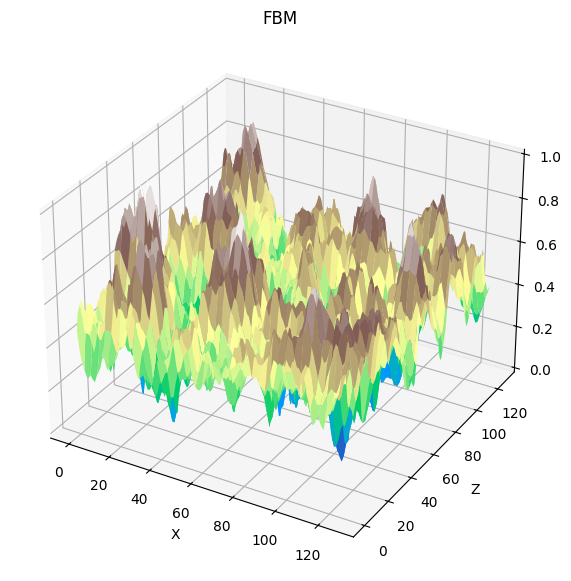

In [6]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

X, Y = np.meshgrid(
    range(terrain["width"]),
    range(terrain["height"])
)

ax.plot_surface(X, Y, hm,cmap=render.get("cmap", "terrain"))

ax.set_title(noise_type.upper())
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
plt.show()